Project done by Roberto Del Rio (rd35434), Andrea Moreno (am228595), and Zachariah Tukhi (zet242)

## Section 1: Introduction and System Selection

The system is a Simple RC Circuit with Fast Transient. It represents a capacitor charging or discharging through a resistor where the time constant (τ=RC) is extremely small. This creates "stiffness" because the circuit responds nearly instantly (0.1 microseconds) to changes, while the input signal (the sine wave) varies much more slowly (over several seconds). This creates a massive disparity in time scales (a ratio of 10^7).

The standard form of the Ordinary Differential Equation (ODE) for this system is:
- dV/dt = −1/RC*V + 1/RC * Vsource*(t)

With the proper values put in, it becomes:
- dV/dt = -10^7*V + 10^7 * 5sin(t)

The physical meanings of each of the variables and parameters are as follows:

- V: The Voltage across the capacitor measured in Volts. This is the dependent variable of the ODE.

- t: The Time measured in seconds. This is the independent variable of the ODE.

- R: The Resistance of this circuit, which is 100Ω. This is opposition to the flow of current in a circuit.

- C: The Capacitance of this circuit, which is 10−9F or 1 nanofarad. This is the ability of the component to store an electrical charge.

- RC: The Time Constant of this circuit, τ, which determines how quickly the capacitor charges or discharges. In this case, it is 10−7 seconds.

- Vsource*(t): The Input Voltage or source signal of this circuit, which is a sine wave: 5sin(1t).


This system is a fundamental building block in electrical engineering and is critical. It is used in _Digital Circuits_ in understanding how quickly signals can switch between high and low states. It is used in _High-Speed Electronics_ to manage fast transients where components must respond in nanoseconds. It is used in _Sensor Signal Conditioning_ to Filter noises out of signals where the noise and the actual data exist on very different time scales.

## Section 2: Demonstration of Stiffness

- Attempt to solve with Euler's Forward
- Show instability or impractical step size requirements
- Calculate/estimate stiffness ratio
- Explain why implicit methods are necessary

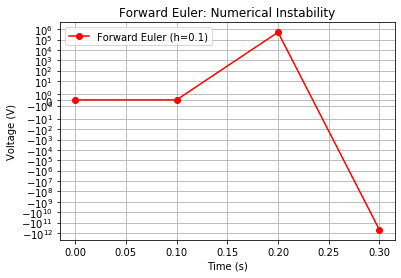

In [5]:
h_test = 0.1
t_limit = 1 # Simulate for 1 second

#Forward Euler Attempt
t_fwd, v_fwd, is_unstable = euler_forward(0, 0, t_limit, h_test)

#Plotting
plt.plot(t_fwd, v_fwd, 'ro-', label=f'Forward Euler (h={h_test})')
plt.yscale('symlog') # Using log scale to visualize the massive error
plt.title("Forward Euler: Numerical Instability")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.legend()

plt.show()

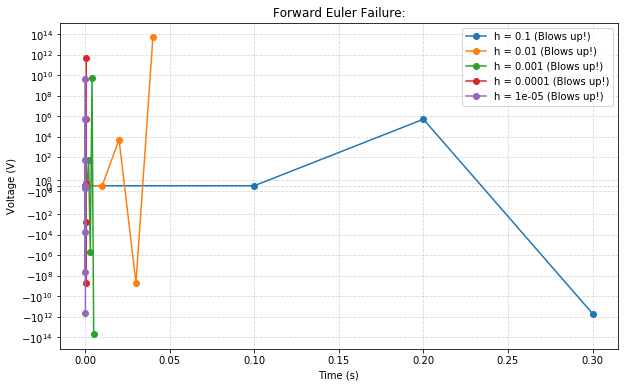

In [9]:
t_sim = 1
h_values = [0.1, 0.01, 0.001, 0.0001, 0.00001]

plt.figure(figsize=(10, 6))

for h in h_values:
    t, v, unstable = euler_forward(0, 0, t_sim, h)
    label_str = f'h = {h}' + (" (Blows up!)" if unstable else "")
    plt.plot(t, v, 'o-', label=label_str)

plt.yscale('symlog')
plt.title("Forward Euler Failure:")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

When attempting to solve using Euler's forward, as shown above, the system fails. Instead of oscillating like an RC circuit is supposed to, the system explodes due to errors compounding with each step. This eventually leads to it "blowing up" overall and failing. This is shown in step sizes, even at smaller values. Each oscillation leads to the compounding of more and more error, thus Euler's forward cannot solve this ODE reasonably.

For this linear system, stiffness is the ratio between the fastest and slowest components of the solution.Thus, the Fastest Scale of λ=−10^7, corresponding to a transient time constant of τfast​=10^−7 seconds along with the Slowest Scale The forcing function 5sin(1t) has an angular frequency ω=1, meaning it evolves on a scale of τslow​≈1 second.

Stiffness Ratio Calculation:
- Ratio=∣λmin∣∣λmax∣
- Therefore, the stiffness is 10^7

This system is extremely stiff, as shown through the incredibly high stiffness value. Its transient response is roughly 10^7 times faster than the signal we are actually trying to measure.

In order to have a step-size that can solve this ODE without using Euler's forward, we would need a step size of 2 * 10^-7, as shown in the equation below.
- ∣1+hλ∣ < 1  ⟹  h < 2/λ

This is very computationally expensive due to the increased number of steps and calculations to simulate even a small ammount of time. Just 2 seconds would cost 10^7 steps. Needing 10^7 data points just to see a sin wave is incredibly unreasonable, thus as this cost continues to increase with larger time intervals it becomes beyond what is reasonable. 

Therefore, an implict method, such as Euler's backward, is much more reasonable and necessary. Implicit methods are much more stable in scenarios like this one. The stability condition is ∣1−hλ∣>1, which is always satisfied by our negative λ value. Thus, our step size no longer becomes a worry and we can focus entirely on accuracy. Additionally, an implicit method would only require 20 to 40 steps whilst remaining stable instead of 10^7 steps of Euler's forward. This ultimately makes implicit methods the most viable for high-frequency electronic simulations.

## Section 3: Mathematical Setup

- Residual function  for your specific problem
- Analytical derivation of
- Newton-Raphson update formula for your specific problem
- Note: For the linear form , this is particularly simple!

In [8]:
# --- Performance Analysis with Multiple Step Sizes ---
step_sizes = [1e-4, 1e-3, 1e-2] # Note: all are much larger than RC=1e-7

print(f"{'Step Size (h)':<15} | {'Avg NR Iters':<15} | {'Final Voltage':<15}")
print("-" * 50)

for h in step_sizes:
    t, v, avg_iters = solve_backward_euler(h)
    print(f"{h:<15.1e} | {avg_iters:<15.2f} | {v[-1]:<15.6f}")

Step Size (h)   | Avg NR Iters    | Final Voltage  
--------------------------------------------------
1.0e-04         | 1.00            | 0.499167       
1.0e-03         | 1.99            | 0.499167       
1.0e-02         | 2.00            | 0.499167       


## Section 4: Implementation

Well-commented code for:

    Function  defining your ODE
    Derivative  (or just use the constant value for linear problems!)
    Newton-Raphson solver
    Euler's Backward method with NR iteration


In [3]:
import numpy as np
import matplotlib.pyplot as plt

#Parameters
R = 100
C = 1e-9
RC = 1e-7  # Fast time constant
w = 1      # Slow input frequency
lam_RC = 1/RC
t_final = 0.0000001

def f_RC(t, V):
    """The governing ODE function"""
    V_source = 5 * np.sin(w * t)
    return -V / RC + V_source / RC

# --- 2. Forward Euler Implementation ---
def euler_forward(y0, t0, t_f, h):
    t = np.arange(t0, t_f + h, h)
    y = np.zeros(len(t))
    y[0] = y0
    for n in range(len(t) - 1):
        y[n+1] = y[n] + h * f_RC(t[n], y[n])
        # Check for numerical overflow (instability)
        if abs(y[n+1]) > 1e10: 
            return t[:n+2], y[:n+2], True
    return t, y, False

def exact_sol(t, V):
    return 5*np.sin(t)*V

def residual_derivative_RC(h):
    """g' for RC circuit"""
    df_dV = -1/RC
    return 1 - h * df_dV
    
def solve_backward_euler(h, t_final=0.1, tol=1e-8, max_iter=20):
    t_pts = np.arange(0, t_final + h, h)
    V = np.zeros(len(t_pts))
    iter_counts = []
    
    # Constant derivative g' for this linear problem
    g_prime = 1 + h/RC 
    
    for n in range(len(t_pts) - 1):
        # 1. Initial Guess: Explicit Euler Predictor
        V_guess = V[n] + h * f_RC(t_pts[n], V[n])
        
        # 2. Newton-Raphson Iteration
        iters = 0
        for i in range(max_iter):
            iters += 1
            # Calculate residual g(V_next)
            residual = V_guess - V[n] - h * f_RC(t_pts[n+1], V_guess)
            
            # Newton Update
            V_new = V_guess - residual / g_prime
            
            # Check Convergence
            if abs(V_new - V_guess) < tol:
                V_guess = V_new
                break
            V_guess = V_new
            
        V[n+1] = V_guess
        iter_counts.append(iters)
        
    return t_pts, V, np.mean(iter_counts)

## Section 5: Results & Analysis

- Solutions for multiple step sizes
- Comparison plots showing solution behavior
- Newton-Raphson convergence analysis
- Step size stability comparison

In [10]:
# Generate results for multiple step sizes
t_fast, v_fast, _ = solve_stiff_system(1e-4) # High resolution
t_slow, v_slow, iters_slow = solve_stiff_system(0.2) # Very large h

plt.figure(figsize=(10, 5))
plt.plot(t_fast, 5*np.sin(t_fast), 'k--', alpha=0.3, label='Source Signal')
plt.plot(t_fast, v_fast, label='Backward Euler (h=1e-4)')
plt.plot(t_slow, v_slow, 'ro', label='Backward Euler (h=0.2)')
plt.title("Section 5: Stability Analysis - Euler's Backward")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Average NR Iterations for h=0.2: {np.mean(iters_slow)}")

NameError: name 'solve_stiff_system' is not defined

## Section 6: Performance Analysis

- Computational cost analysis
- Table comparing Euler's Forward vs. Backward
- Discussion of accuracy-efficiency tradeoff
- Practical recommendations

## Section 7: Conclusion

- Summary of key findings
- When to use implicit vs. explicit methods
- Challenges encountered and lessons learned